Analyzing result CSVs across different groups to detect any significant trends.

In [142]:
import sys
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from pathlib import Path
import optimal_alpha_csv as opt
from constants import EVALUATED_COSTS_DIR

sns.set_theme(style="whitegrid")      # My recommendation
# or:
# sns.set_theme(style="ticks")
# sns.set_theme(style="darkgrid")

In [132]:
# Accessing data

df_treatment = pd.read_csv("data/metadata/metadata.csv")
df_results = pd.read_csv("data/results/heterogeneous_results/optimal_distance_values.csv")

df_treatment.columns = df_treatment.columns.str.strip()
df_results.columns = df_results.columns.str.strip()
# print(df_treatment.columns)
# print(df_results.columns)

df_treatment['arbor name'] = df_treatment['arbor name'].str.strip() # removing space in front of the arbor names from metadata.csv

# merging dataframes by arbor
combined_df = df_results.merge(df_treatment, left_on='arbor', right_on='arbor name', how='left')
# print(combined_df.head())
print(combined_df.head(10))

for i in range(150, 160):
    print(combined_df.loc[i, "hormone"])



                                               arbor     cost method    G  \
0  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
1  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
2  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
3  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
4  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
5  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
6  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
7  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
8  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
9  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   

   alpha  total squared orthogonal distance experiment  \
0   1.00                           0.914192   PimpiABA   
1   1.00                           0

# Looking at the quantity of arbors that contrast in optimal alpha values belonging to each cost method

In [116]:
def extract_difference_values(arbor_folder):
    folder = Path(arbor_folder)

    alpha_diffs = []
    sq_orthog_dist_diffs = []
    for i, arbor_file in enumerate(folder.glob("*.csv")):
        if i >= 1000: # to prevent errors with encountering an incomplete CSV
            break
        
        homog_opt_info, heterog_opt_info, alpha_diff, sq_orthog_dist_diff = opt.extract_optimal_dist_vals(arbor_file, len(EVALUATED_COSTS_DIR))
        alpha_diffs.append(alpha_diff)
        sq_orthog_dist_diffs.append(sq_orthog_dist_diff)

    return alpha_diffs, sq_orthog_dist_diffs


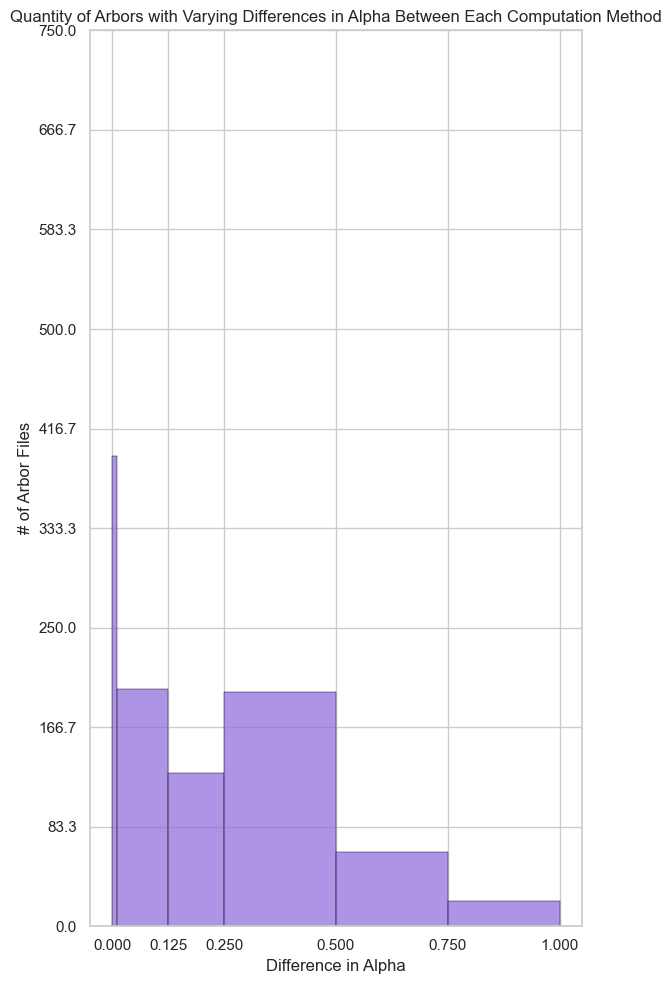

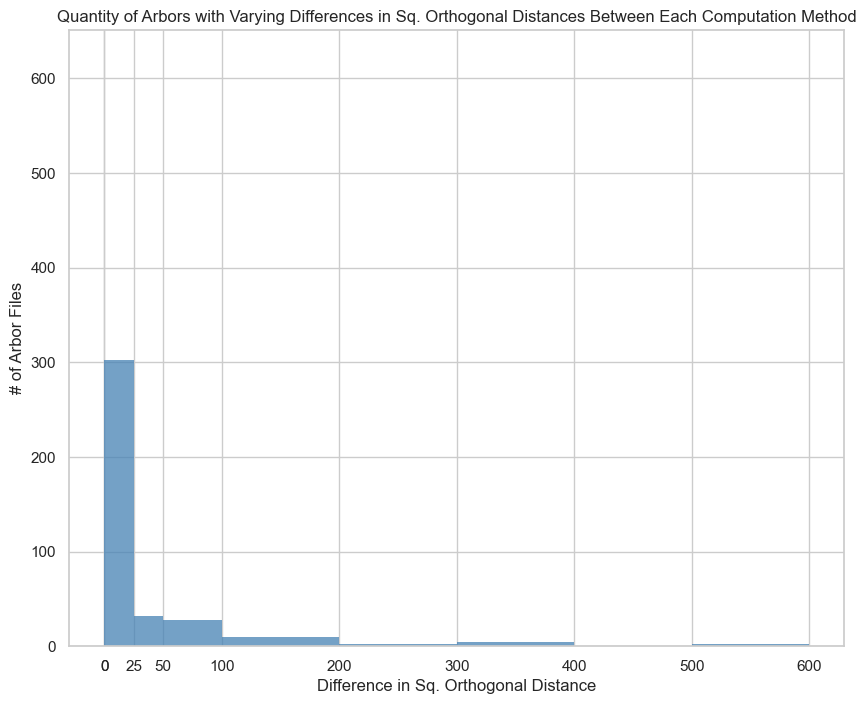

In [117]:
# Creating a histogram that categorizes values based on what range the difference in alpha (between each computation method) falls under

alpha_diffs, sq_orthog_dist_diffs = extract_difference_values(EVALUATED_COSTS_DIR)
plt.figure(figsize=(6, 10))

sns.histplot(alpha_diffs,
    bins=[0, .01, .125, 0.25, 0.5, 0.75, 1.0],
    color="mediumpurple",
    edgecolor="black",
    stat="count"
    )

plt.yticks(np.linspace(0, 750, 10))
plt.xticks([0, 0.125, 0.25, 0.5, 0.75, 1.0])
plt.xlabel("Difference in Alpha")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Alpha Between Each Computation Method")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

sns.histplot(
    sq_orthog_dist_diffs,
    bins=[0, .01, 25, 50, 100, 200, 300, 400, 500, 600],
    color="steelblue",
    edgecolor="black",
    stat="count"
)
plt.xticks([0, .01, 25, 50, 100, 200, 300, 400, 500, 600])
plt.xlabel("Difference in Sq. Orthogonal Distance")
plt.ylabel("# of Arbor Files")
plt.title("Quantity of Arbors with Varying Differences in Sq. Orthogonal Distances Between Each Computation Method")
plt.show()

# Looking at data by hormone treatment


In [ ]:
# list of hormone treatmenets: no_hormone, no_ga, lo_ga, hi_ga, iaa, no_iaa, _10_aba, _1_aba, no_aba, hi_cyto, lo_cyto, no_cyto, 
# _5_acc, no_acc, _1_acc

In [109]:


def distribution_of_alpha_values_matplotlib(hormone, super_title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    #print(treatment_all)
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == ' homogeneous']
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == ' heterogeneous']

    ax[0].hist(treatment_all['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='purple', edgecolor='black')

    ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[0].set_title("Homogeneous and Heterogeneous", fontsize=16)

        # Homogeneous
    ax[1].hist(treatment_homogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='blue', edgecolor='black')

    ax[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[1].set_title("Homogeneous", fontsize=16)

        # Heterogeneous
    ax[2].hist(treatment_heterogeneous['alpha'], bins=[0, 0.25, 0.5, 0.75, 1.0], color='red', edgecolor='black')

    ax[2].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[2].set_title("Heterogeneous", fontsize=16)

    fig.supxlabel("Optimal Alpha Values", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=16)

    plt.show()

def distribution_of_sq_orthog_dist_values_matplotlib(hormone, super_title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    #print(treatment_all)
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == ' homogeneous']
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == ' heterogeneous']

    ax[0].hist(treatment_all['total squared orthogonal distance'], color='green', edgecolor='black')

    #ax[0].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[0].set_title("Homogeneous and Heterogeneous", fontsize=16)

        # Homogeneous
    ax[1].hist(treatment_homogeneous['total squared orthogonal distance'], color='yellow', edgecolor='black')

    #ax[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[1].set_title("Homogeneous", fontsize=16)

        # Heterogeneous
    ax[2].hist(treatment_heterogeneous['total squared orthogonal distance'], color='blue', edgecolor='black')

    #ax[2].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[2].set_title("Heterogeneous", fontsize=16)

    fig.supxlabel("Optimal Alpha Values", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=16)

    plt.show()


# using seaborn
def distribution_of_alpha_values(hormone, super_title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == " homogeneous"]
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == " heterogeneous"]

    bins = [0, 0.25, 0.5, 0.75, 1.0]

    sns.histplot(data=treatment_all, x="alpha", bins=bins, color="purple", edgecolor="black", ax=ax[0])
    
    sns.histplot(
        data=treatment_homogeneous,
        x="alpha",
        bins=bins,
        color="royalblue",
        alpha=0.5,
        edgecolor="black",
        label="Homogeneous",
        ax=ax[1]
    )
    sns.histplot(
        data=treatment_heterogeneous,
        x="alpha",
        bins=bins,
        color="firebrick",
        alpha=0.5,
        edgecolor="black",
        label="Heterogeneous",
        ax=ax[1]
    )
    ax[1].legend(title="Cost Method")
    titles = ["Homogeneous and Heterogeneous Combined", "Homogeneous and Heterogeneous Seperate"]

    for axis, title in zip(ax, titles):
        axis.set_xticks(bins)
        axis.set_title(title, fontsize=16)
        
    fig.supxlabel("Optimal Alpha Value", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def distribution_of_sq_orthog_dist_value(hormone, super_title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 8))

    treatment_all = combined_df[combined_df["hormone"].isin(hormone)]
    treatment_homogeneous = treatment_all[treatment_all["cost method"] == " homogeneous"]
    treatment_heterogeneous = treatment_all[treatment_all["cost method"] == " heterogeneous"]

    bins = [0, 0.25, 0.5, 0.75, 1.0]

    sns.histplot(data=treatment_all, x="total squared orthogonal distance", bins=bins, color="purple", edgecolor="black", ax=ax[0])
    
    sns.histplot(
        data=treatment_homogeneous,
        x="total squared orthogonal distance",
        bins=bins,
        color="royalblue",
        alpha=0.5,
        edgecolor="black",
        ax=ax[1]
    )
    sns.histplot(
        data=treatment_heterogeneous,
        x="total squared orthogonal distance",
        bins=bins,
        color="firebrick",
        alpha=0.5,
        edgecolor="black",
        ax=ax[1]
    )
    titles = ["Homogeneous and Heterogeneous", "Homogeneous", "Heterogeneous"]

    for axis, title in zip(ax, titles):
        axis.set_xticks(bins)
        axis.set_title(title, fontsize=16)
        
    fig.supxlabel("Optimal Alpha Value", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


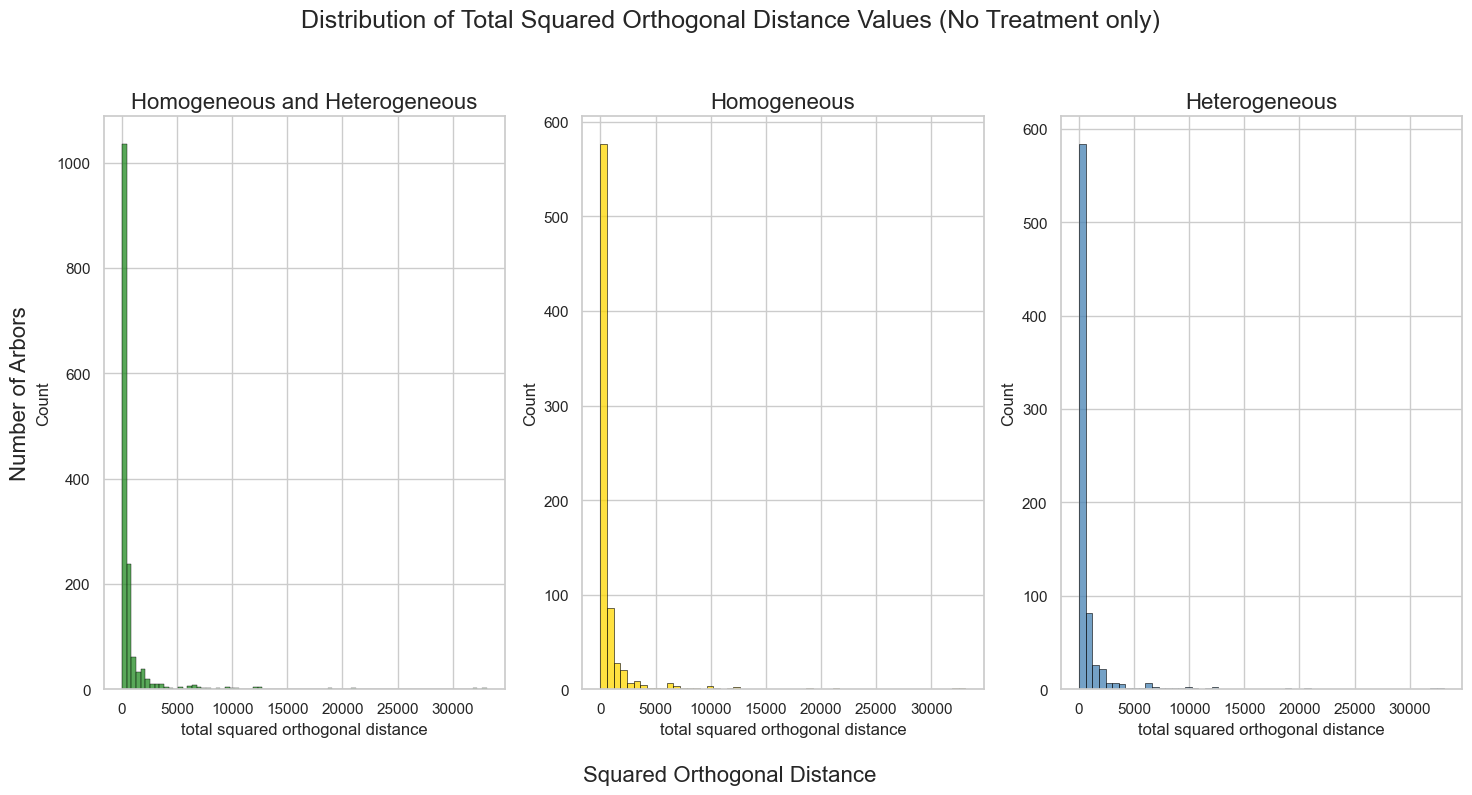

In [98]:
distribution_of_sq_orthog_dist_values([" None"], "Distribution of Total Squared Orthogonal Distance Values (No Treatment only)")

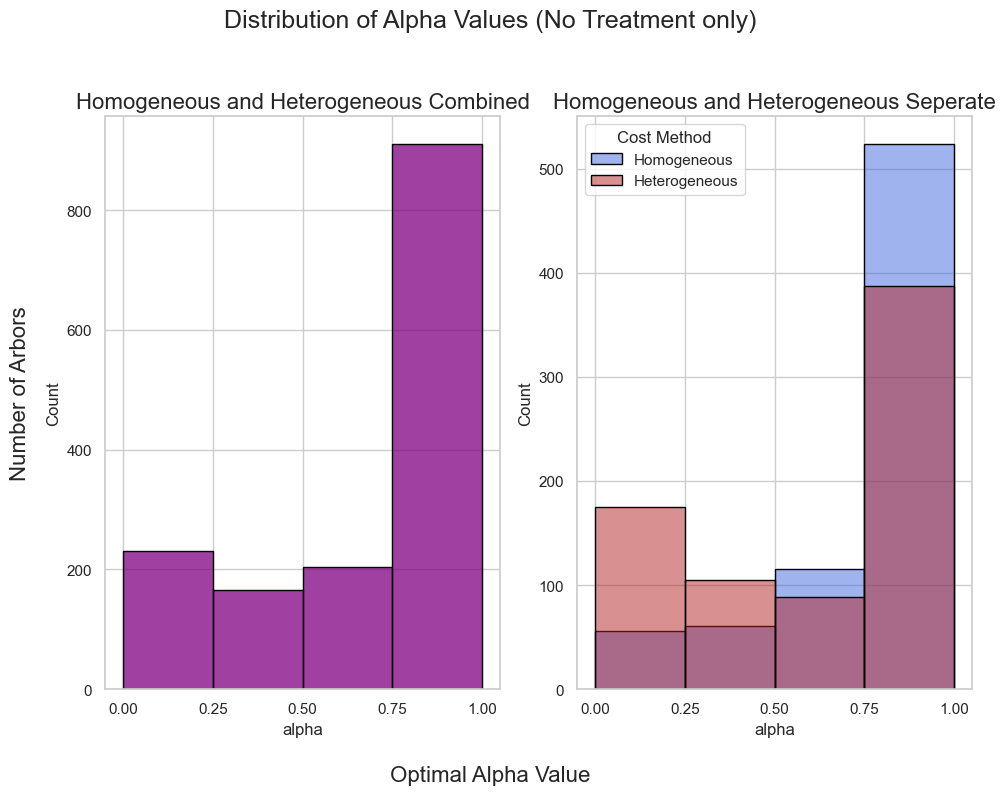

In [110]:
# Distribution of Alpha Values (No Treatment only)
distribution_of_alpha_values([" None"], "Distribution of Alpha Values (No Treatment only)")

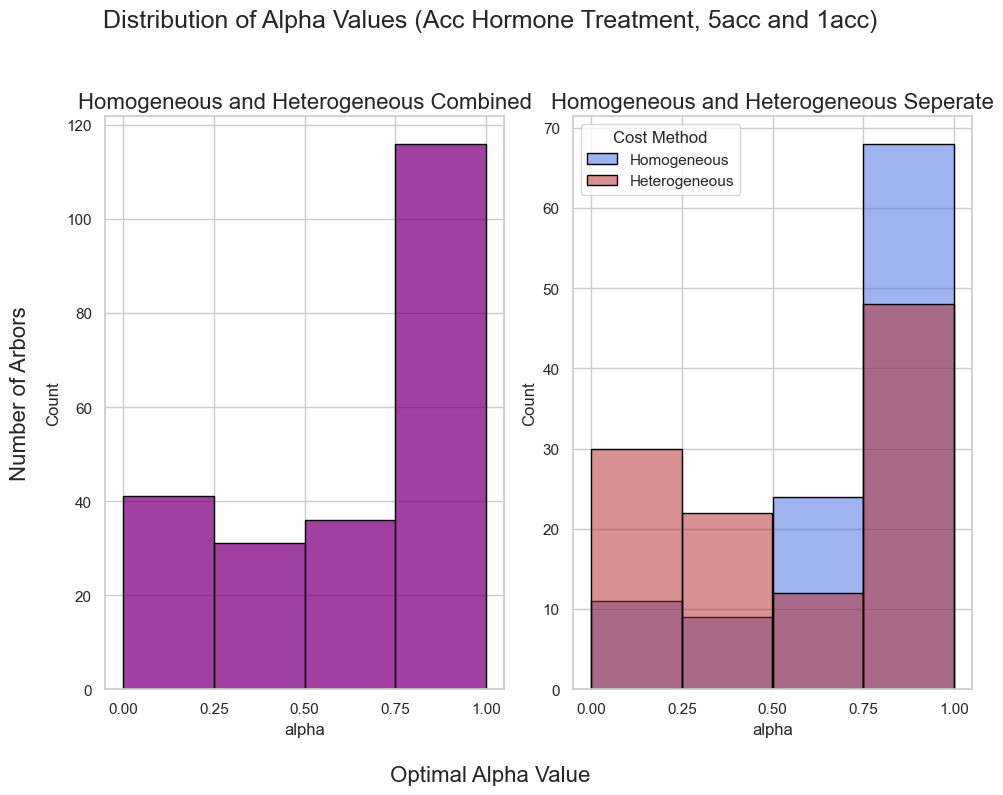

In [111]:
# Distribution of Alpha Values (No GA, No IAA, No ABA, No Cyto, No Acc) << TODO: Run again since this does not include all files yet (nothing is in the noiaa category)


distribution_of_alpha_values([" noga", " noiaa", " noaba", " nocyto", " noacc"], "Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)")


Empty DataFrame
Columns: [arbor, cost method, G, alpha, total squared orthogonal distance, experiment, arbor name, day, Picture #, genotype, replicate, condition, hormone]
Index: []


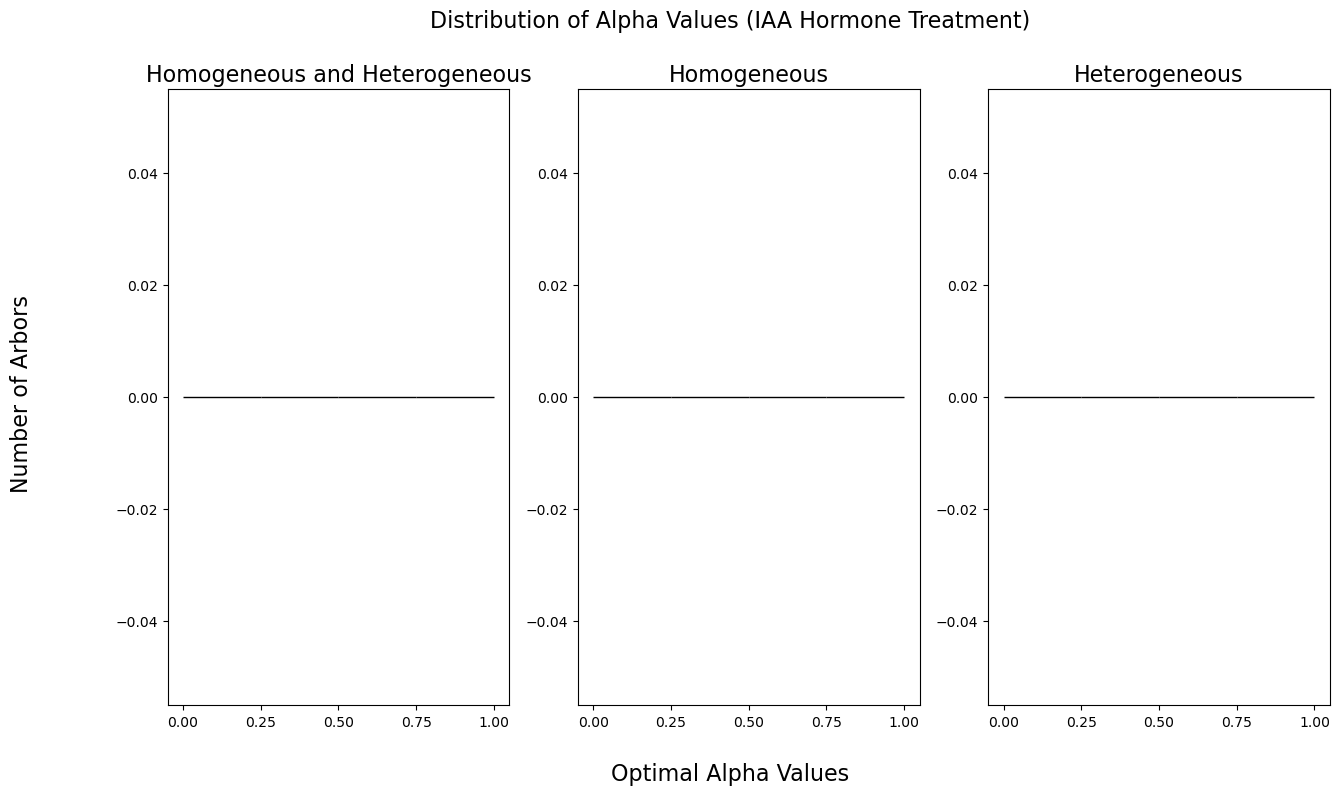

In [ ]:
# Distribution of Alpha Values (IAA Hormone Treatment) << TODO: Run when ALL CSV files calculating homogeneous/heterogenous values have been generated 
distribution_of_alpha_values([" iaa"], "Distribution of Alpha Values (IAsA Hormone Treatment)")


Empty DataFrame
Columns: [arbor, cost method, G, alpha, total squared orthogonal distance, experiment, arbor name, day, Picture #, genotype, replicate, condition, hormone]
Index: []


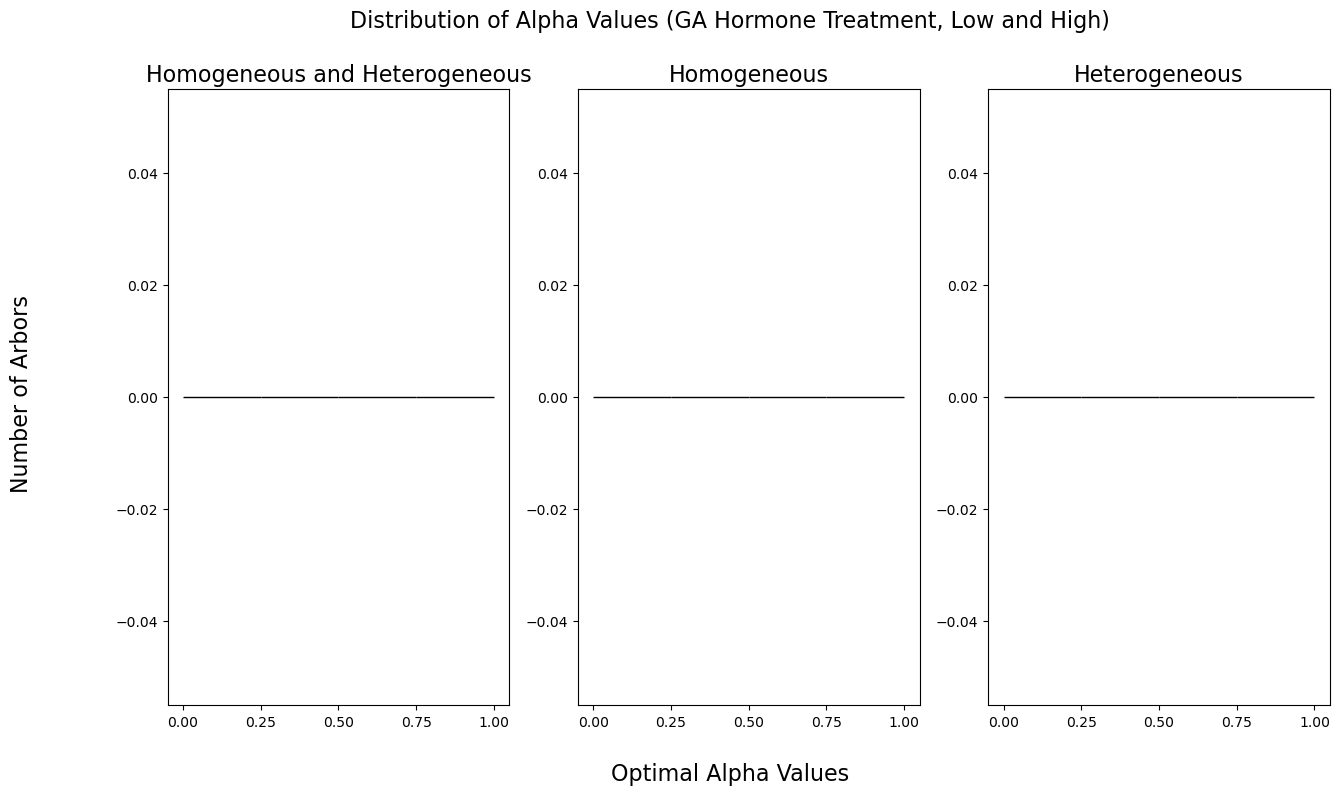

In [ ]:
# Distribution of Alpha Values (GA Hormone Treatment, Low and High) << TODO: Run when ALL CSV files calculating homogeneous/heterogenous values have been generated 
distribution_of_alpha_values([" loga", " higa"], "Distribution of Alpha Values (GA Hormone Treatment, Low and High)")

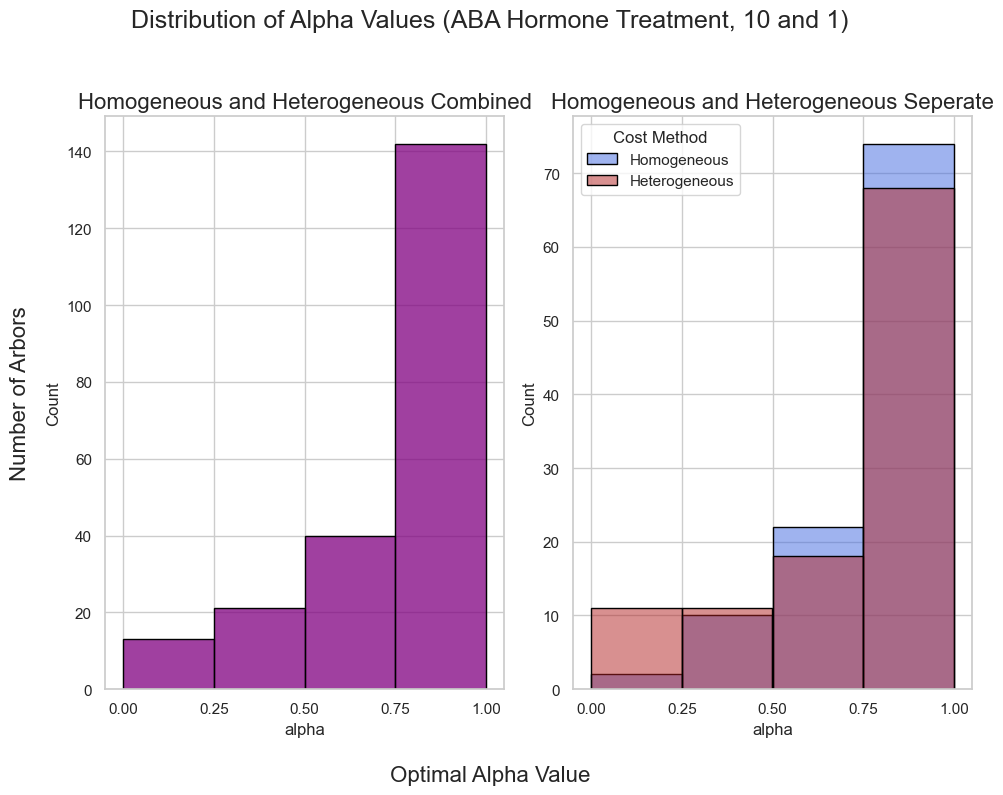

In [112]:
# Distribution of Alpha Values (ABA Hormone Treatment, 10 and 1)
distribution_of_alpha_values([" 10aba", " 1aba"], "Distribution of Alpha Values (ABA Hormone Treatment, 10 and 1)")

Empty DataFrame
Columns: [arbor, cost method, G, alpha, total squared orthogonal distance, experiment, arbor name, day, Picture #, genotype, replicate, condition, hormone]
Index: []


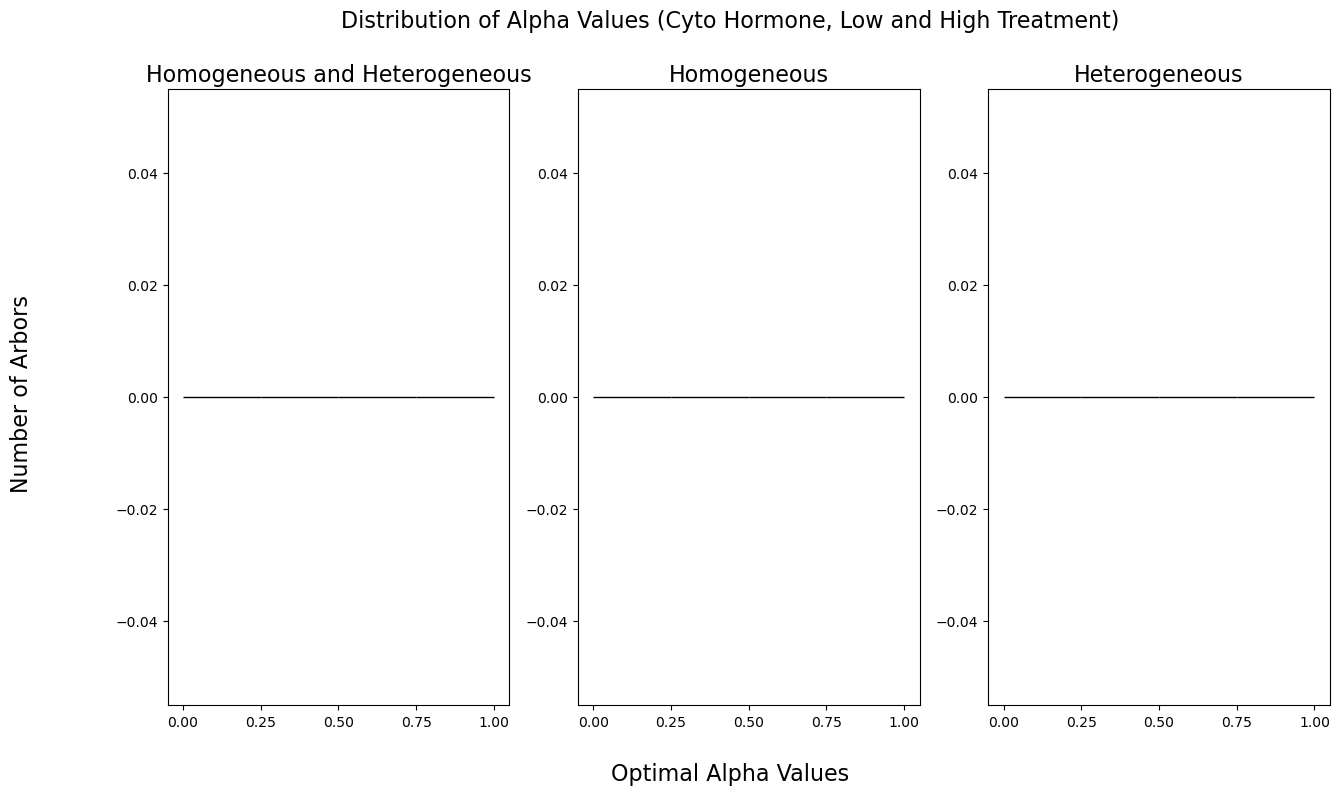

In [86]:
# Distribution of Alpha Values (Cyto Hormone, Low and High Treatment)
distribution_of_alpha_values([" hicyto", " locyto"], "Distribution of Alpha Values (Cyto Hormone, Low and High Treatment)")


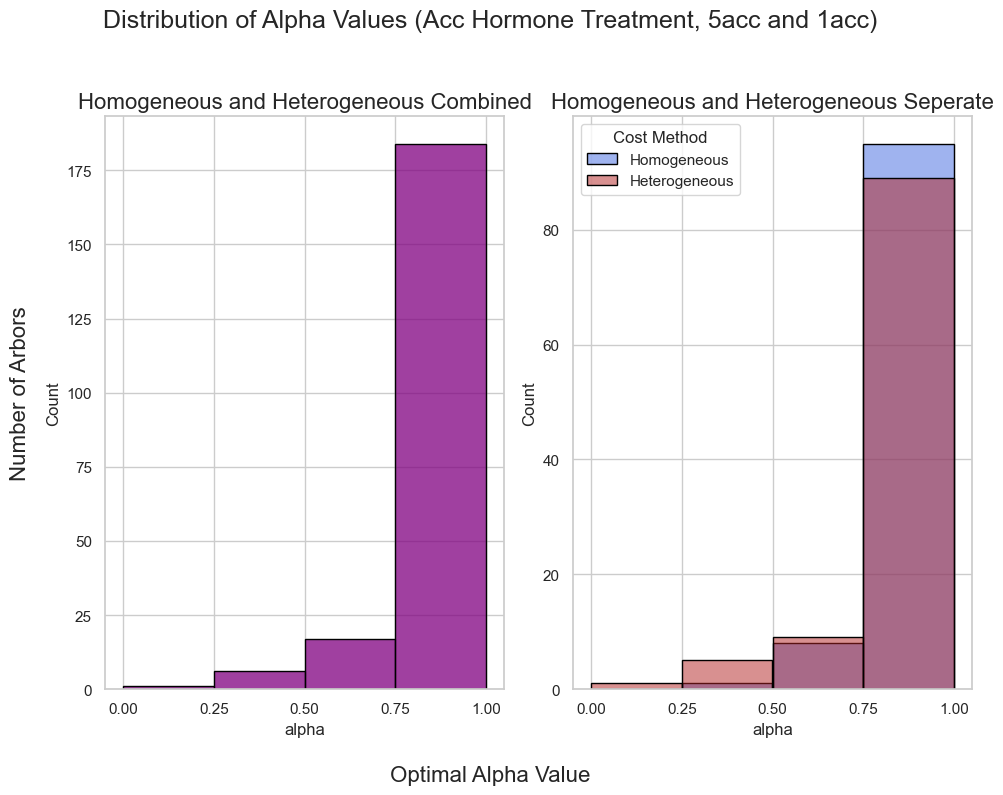

In [113]:
# Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)
distribution_of_alpha_values([" 5acc", " 1acc"], "Distribution of Alpha Values (Acc Hormone Treatment, 5acc and 1acc)")


# Comparing optimal alpha values by ideotype

In [140]:
# Accessing necessary data
#df_results = pd.read_csv("data/results/heterogeneous_results/optimal_distance_values.csv")

df_scoring = pd.read_csv("data\scoring-data\manual_scoring_last_day_fullname_ver.csv")
df_scoring["arbor name"] = df_scoring["arbor name"].str.strip()

matching = set(df_results['arbor']) and set(df_scoring['arbor name'])
print(f"# of matching arbors: {len(matching)}")


df_combined_ideotype = df_results.merge(df_scoring, left_on='arbor', right_on='arbor name', how='left', indicator=True)
print(df_combined_ideotype.head(10))

for i in range(2000, 2010):
    print(df_combined_ideotype.loc[i, 'ideotype (T/C/B)'])
    #print(df_combined_ideotype.loc[i, 'arbor'])
    #print(df_combined_ideotype.loc[i, 'arbor name'])



# of matching arbors: 6544
                                               arbor     cost method    G  \
0  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
1  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
2  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
3  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
4  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
5  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
6  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
7  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   
8  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...     homogeneous  0.0   
9  pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...   heterogeneous  0.0   

   alpha  total squared orthogonal distance arbor name  metadata day  \
0   1.00                           0.914192        Na

In [156]:
def distribution_of_alpha_by_ideotype(ideotype, super_title):
    """
    Creates two histograms of optimal alpha values for a given ideotype.

    Parameters
    ----------
    ideotype : str or list
        One ideotype (e.g. "T") or a list of ideotypes
        (e.g. ["T", "dT"]).

    super_title : str
        Figure title.
    """

    fig, ax = plt.subplots(1, 2, figsize=(10, 8))

    # Allow either a single ideotype or a list
    if isinstance(ideotype, str):
        ideotype = [ideotype]

    ideotype_all = df_combined_ideotype[df_combined_ideotype["ideotype (T/C/B)"].isin(ideotype)]

    ideotype_homogeneous = ideotype_all[ideotype_all["cost method"] == " homogeneous"]

    ideotype_heterogeneous = ideotype_all[ideotype_all["cost method"] == " heterogeneous"]

    bins = [0, 0.25, 0.5, 0.75, 1.0]

    # -----------------------------
    # Combined histogram
    # -----------------------------
    sns.histplot(
        data=ideotype_all,
        x="alpha",
        bins=bins,
        color="mediumpurple",
        edgecolor="black",
        stat="count",
        ax=ax[0]
    )

    ax[0].set_title("Combined Distribution")
    ax[0].set_xticks(bins)

    # -----------------------------
    # Overlay histogram
    # -----------------------------
    sns.histplot(
        data=ideotype_homogeneous,
        x="alpha",
        bins=bins,
        color="royalblue",
        alpha=0.5,
        edgecolor="black",
        stat="count",
        label="Homogeneous",
        ax=ax[1]
    )

    sns.histplot(
        data=ideotype_heterogeneous,
        x="alpha",
        bins=bins,
        color="firebrick",
        alpha=0.5,
        edgecolor="black",
        stat="count",
        label="Heterogeneous",
        ax=ax[1]
    )

    ax[1].set_title("Homogeneous vs. Heterogeneous")
    ax[1].set_xticks(bins)
    ax[1].legend(title="Cost Method")

    fig.supxlabel("Optimal Alpha", fontsize=16)
    fig.supylabel("Number of Arbors", fontsize=16)
    fig.suptitle(super_title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

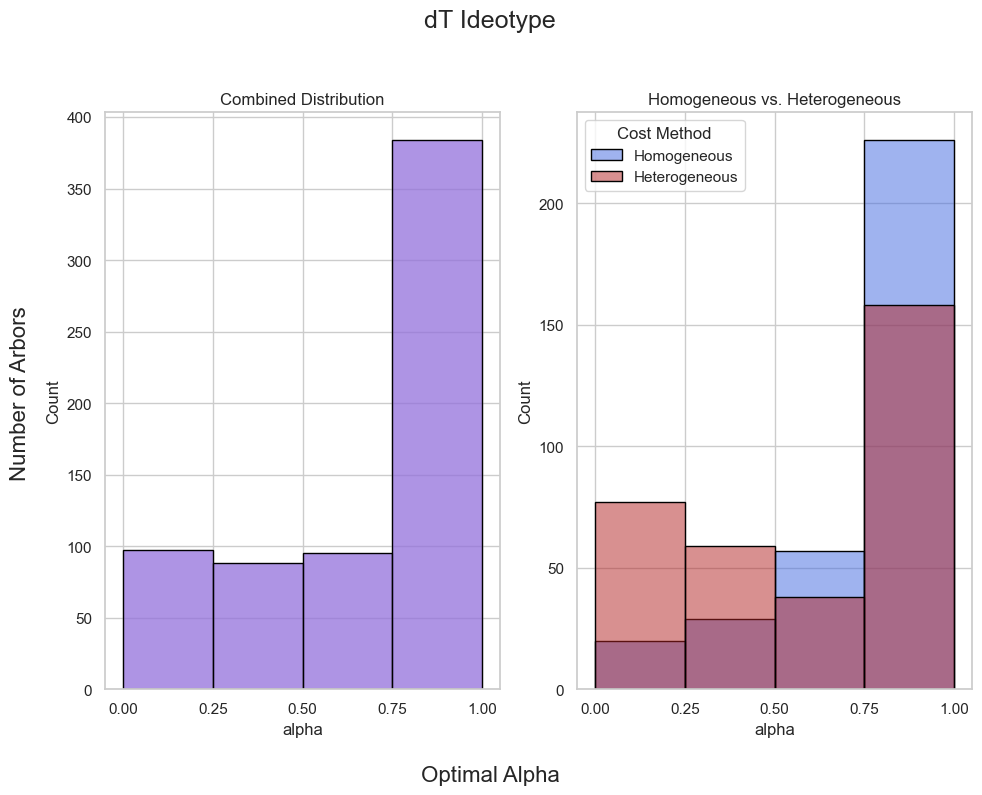

In [ ]:
distribution_of_alpha_by_ideotype("dT", "Droopy Teleophone Pole Ideotype")

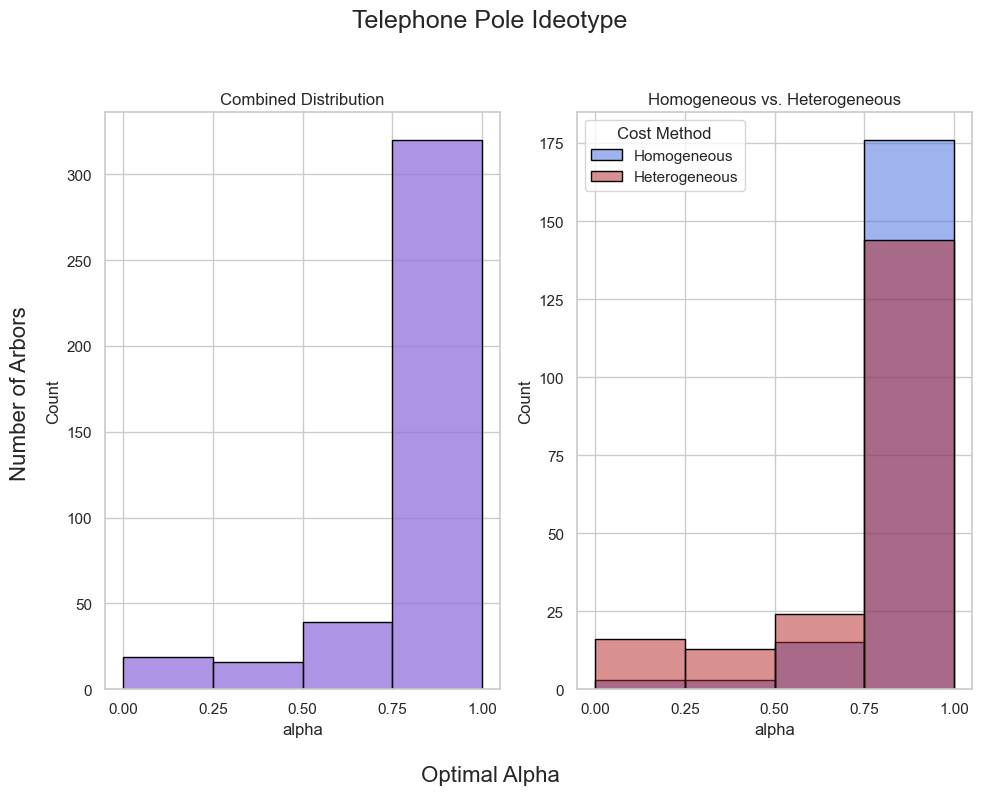

In [158]:
distribution_of_alpha_by_ideotype("T", "Telephone Pole Ideotype")

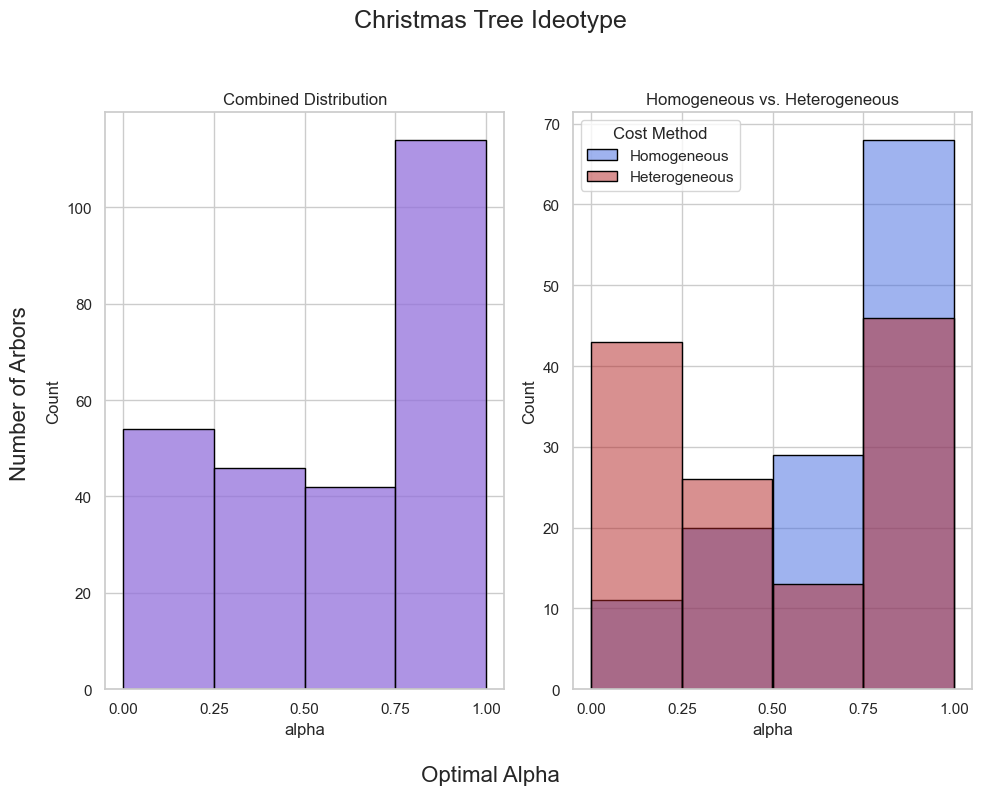

In [159]:
distribution_of_alpha_by_ideotype("C", "Christmas Tree Ideotype")

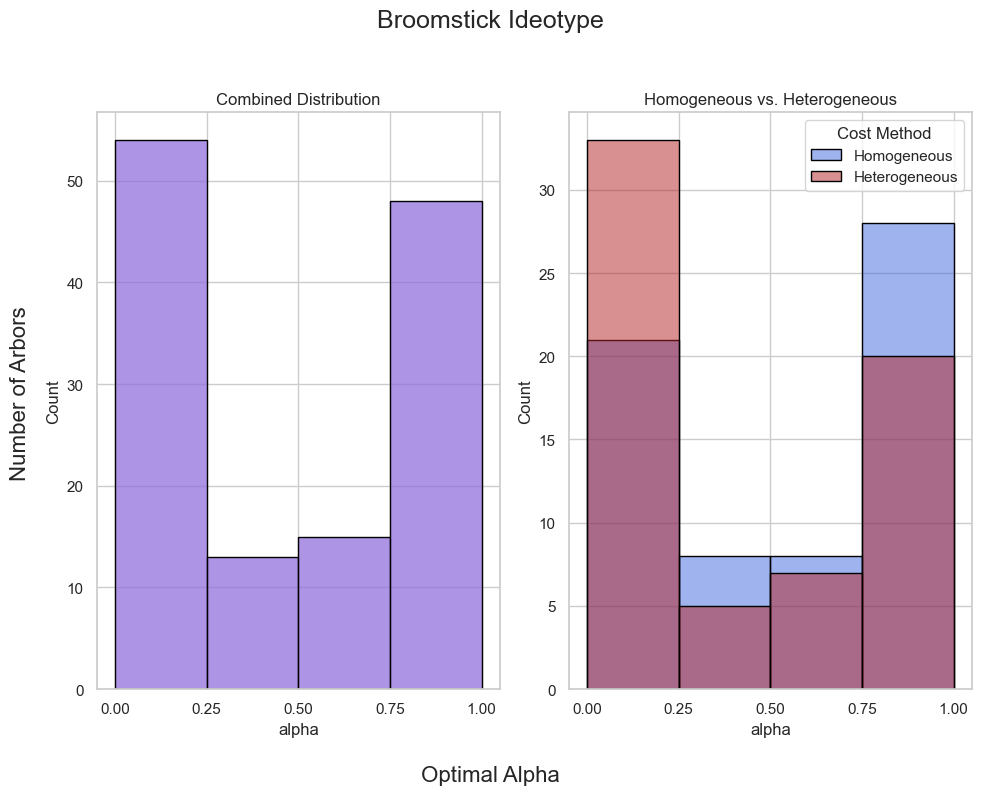

In [160]:
distribution_of_alpha_by_ideotype("B", "Broomstick Ideotype")

In [161]:
dT_df = df_combined_ideotype[df_combined_ideotype["ideotype"] == "dT"]

KeyError: 'ideotype'

# Comparing optimal alpha values for Salt vs. Control conditions 